Pada Bab 4, telah dibahas dua jenis fitur yang merepresentasikan properti data, yaitu fitur kontinu yang mendeskripsikan kuantitas dan fitur kategorikal yang berasal dari daftar tetap. Namun, terdapat jenis fitur ketiga yang sering dijumpai dalam berbagai aplikasi, yakni data teks. Sebagai contoh, dalam klasifikasi email masuk sebagai pesan sah atau spam, konten email tersebut memegang peranan krusial. Begitu pula dalam analisis opini politik melalui pidato atau media sosial, serta dalam layanan pelanggan untuk mengidentifikasi intensi pesan guna menentukan departemen yang tepat secara otomatis.

Data teks biasanya direpresentasikan sebagai untaian karakter (*strings*) dengan panjang yang bervariasi. Karakteristik ini sangat berbeda dengan fitur numerik yang telah dipelajari sebelumnya. Oleh karena itu, diperlukan pemrosesan awal yang spesifik sebelum algoritma pembelajaran mesin dapat diterapkan pada data tersebut.

## Types of Data Represented as Strings

Sebelum mempelajari tahapan pemrosesan data teks dalam pembelajaran mesin, penting untuk memahami berbagai jenis data *string* yang mungkin ditemui. Meskipun data teks biasanya direpresentasikan sebagai *string*, tidak semua fitur *string* harus diperlakukan sebagai teks. Secara umum, terdapat empat kategori data *string*:

* **Data Kategorikal**: Data yang berasal dari daftar tetap, seperti pilihan warna pada menu *drop-down*. Kita dapat memverifikasi jenis data ini dengan memeriksa nilai unik dan frekuensi kemunculannya, serta melakukan konsolidasi jika terdapat kesalahan penulisan yang merujuk pada kategori yang sama.
* **String Bebas yang Dapat Dipetakan ke Kategori**: Data ini muncul ketika pengguna mengisi kolom teks secara manual (misalnya nama warna). Variasinya bisa sangat beragam, mulai dari kesalahan ketik hingga deskripsi yang sangat spesifik atau unik. Pendekatan terbaik biasanya adalah memetakan data ini ke dalam kategori yang masuk akal bagi aplikasi, meskipun proses ini membutuhkan upaya manual yang besar.
* **Data String Terstruktur**: Data yang memiliki struktur mendasar tertentu namun tidak sesuai dengan kategori tetap, seperti alamat, nama orang, tanggal, atau nomor telepon. Penanganan jenis data ini sangat bergantung pada konteks domain dan sering kali sulit untuk diparsing secara otomatis.
* **Data Teks Bebas**: Kategori ini terdiri dari frasa atau kalimat lengkap, seperti cuitan media sosial, ulasan hotel, hingga isi ensiklopedia. Dalam analisis teks, kumpulan data ini disebut sebagai **korpus**, dan setiap titik data tunggal (satu teks) disebut sebagai **dokumen**. Istilah-istilah ini merupakan standar yang digunakan dalam komunitas *Information Retrieval* (IR) dan *Natural Language Processing* (NLP).

## Example Application: Sentiment Analysis of Movie Reviews

Sebagai contoh utama dalam bab ini, kita akan menggunakan dataset ulasan film dari situs IMDb yang dikumpulkan oleh peneliti dari Stanford, Andrew Maas. Dataset ini berisi teks ulasan beserta label yang menunjukkan apakah ulasan tersebut bersifat "positif" atau "negatif".

Situs IMDb sendiri sebenarnya menggunakan skala penilaian dari 1 hingga 10. Namun, untuk menyederhanakan pemodelan, data tersebut diringkas menjadi klasifikasi dua kelas: ulasan dengan skor 6 ke atas diberi label positif, sedangkan sisanya dilabeli negatif. Setelah data diekstrak, dataset ini tersedia dalam bentuk berkas teks yang terbagi ke dalam dua folder terpisah untuk data pelatihan dan data pengujian, di mana masing-masing folder tersebut memiliki subfolder `pos` dan `neg`.

In [1]:
import os
import tarfile
import urllib.request
from sklearn.datasets import load_files

# URL dataset
URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
DATA_DIR = "data"
ARCHIVE_PATH = os.path.join(DATA_DIR, "aclImdb_v1.tar.gz")

os.makedirs(DATA_DIR, exist_ok=True)

# download kalau belum ada
if not os.path.exists(ARCHIVE_PATH):
  print("Downloading dataset...")
  urllib.request.urlretrieve(URL, ARCHIVE_PATH)

# extract kalau belum diextract
if not os.path.exists(os.path.join(DATA_DIR, "aclImdb")):
  print("Extracting dataset...")
  with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
    tar.extractall(path=DATA_DIR)

# load data
reviews_train = load_files(os.path.join(DATA_DIR, "aclImdb/train"))

text_train = [doc.decode("utf-8") for doc in reviews_train.data]
y_train = reviews_train.target

print("jumlah data:", len(text_train))
print("contoh:\n", text_train[0][:300])
print("label:", y_train[0])

Extracting dataset...


/tmp/ipykernel_13101/2232840757.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


jumlah data: 75000
contoh:
 Full of (then) unknown actors TSF is a great big cuddly romp of a film.<br /><br />The idea of a bunch of bored teenagers ripping off the local sink factory is odd enough, but add in the black humour that Forsyth & Co are so good at and your in for a real treat.<br /><br />The comatose van driver by
label: 2


Dapat diamati bahwa `text_train` merupakan sebuah daftar yang memiliki panjang 25.000 elemen, di mana setiap elemennya adalah *string* yang berisi ulasan film. Sebagai contoh, pada ulasan dengan indeks ke-1, terdapat beberapa tag HTML seperti pemutus baris (`<br />`). Meskipun keberadaan format HTML tersebut kemungkinan besar tidak akan memberikan dampak signifikan terhadap performa model pembelajaran mesin, langkah pembersihan data untuk menghapus format tersebut sangat disarankan sebelum melanjutkan ke tahap pemrosesan berikutnya.

In [3]:
text_train = [doc.replace("<br />", " ") for doc in text_train]

Tipe data dari setiap entri dalam `text_train` akan bergantung pada versi Python yang Anda gunakan. Pada Python 3, entri tersebut biasanya bertipe `bytes` yang merepresentasikan pengodean biner dari data *string*, sedangkan pada Python 2 entri tersebut bertipe `strings`. Disarankan untuk merujuk pada dokumentasi Python terkait penanganan Unicode dan *string* untuk memahami perbedaannya lebih lanjut.

Dataset ini disusun sedemikian rupa sehingga kelas positif dan negatif memiliki jumlah yang seimbang, artinya terdapat jumlah *string* positif yang sama banyaknya dengan *string* negatif.

In [5]:
import numpy as np
print("Samples per class (training): {}".format(np.bincount(y_train)))

Samples per class (training): [12500 12500 50000]


In [6]:
reviews_test = load_files("data/aclImdb/test/")
text_test, y_test = reviews_test.data, reviews_test.target

print("Number of documents in test data: {}".format(len(text_test)))
print("Samples per class (test): {}".format(np.bincount(y_test)))

text_test = [doc.decode("utf-8").replace("<br />", " ") for doc in text_test]

Number of documents in test data: 25000
Samples per class (test): [12500 12500]


Tugas yang ingin kita selesaikan adalah sebagai berikut: diberikan sebuah ulasan, kita ingin menetapkan label "positif" atau "negatif" berdasarkan konten teks dari ulasan tersebut. Ini merupakan tugas klasifikasi biner standar. Namun, data teks tidak berada dalam format yang dapat ditangani secara langsung oleh model pembelajaran mesin. Kita perlu mengonversi representasi *string* dari teks tersebut ke dalam representasi numerik agar algoritma pembelajaran mesin dapat diterapkan.

## Representing Text Data as a Bag of Words

Salah satu metode representasi teks yang paling sederhana namun efektif dan umum digunakan adalah **Bag-of-Words** (kantong kata). Dalam representasi ini, kita mengabaikan sebagian besar struktur teks seperti paragraf, kalimat, atau format, dan hanya menghitung seberapa sering setiap kata muncul dalam setiap dokumen. Pendekatan ini disebut "bag" karena kita seolah-olah memasukkan semua kata ke dalam satu kantong tanpa mempedulikan urutannya.

Proses penghitungan representasi *bag-of-words* terdiri dari tiga langkah utama:

1.  **Tokenisasi**: Memecah setiap dokumen menjadi kata-kata penyusunnya yang disebut **token** (misalnya, dipisahkan berdasarkan spasi atau tanda baca).
2.  **Membangun Kosakata**: Mengumpulkan semua kata unik yang muncul di seluruh korpus dan memberikan nomor indeks pada masing-masing kata (biasanya secara alfabetis).
3.  **Pengodean**: Untuk setiap dokumen, kita menghitung frekuensi kemunculan setiap kata yang ada dalam kosakata tersebut.

Hasil akhirnya adalah sebuah vektor berisi jumlah kata untuk setiap dokumen. Ini berarti representasi numerik kita memiliki satu fitur untuk setiap kata unik di seluruh dataset. Perlu dicatat bahwa dalam metode ini, urutan kata asli dalam teks menjadi sama sekali tidak relevan.

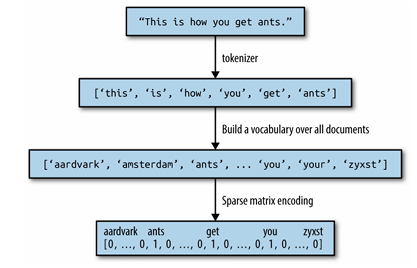

### Applying Bag-of-Words to a Toy Dataset

Representasi *bag-of-words* diimplementasikan dalam `CountVectorizer`, yang merupakan sebuah *transformer* di *scikit-learn*. Untuk melihat cara kerjanya, kita dapat menerapkannya terlebih dahulu pada dataset sederhana (*toy dataset*) yang terdiri dari dua sampel data.

In [8]:
bards_words =["The fool doth think he is wise,",
"but the wise man knows himself to be a fool"]

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

Proses *fitting* pada `CountVectorizer` mencakup tahap tokenisasi data pelatihan dan pembangunan kosakata, yang hasilnya dapat kita akses melalui atribut `vocabulary_`:

In [10]:
print("Vocabulary size: {}".format(len(vect.vocabulary_)))
print("Vocabulary content:\n {}".format(vect.vocabulary_))

Vocabulary size: 13
Vocabulary content:
 {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


Kosakata tersebut terdiri dari 13 kata, mulai dari "be" hingga "wise". Untuk membuat representasi *bag-of-words* pada data pelatihan, kita memanggil metode `transform`:

In [11]:
bag_of_words = vect.transform(bards_words)
print("bag_of_words: {}".format(repr(bag_of_words)))

bag_of_words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


Representasi *bag-of-words* tersebut disimpan dalam bentuk matriks jarang (*sparse matrix*) SciPy yang hanya menyimpan entri bernilai tidak nol. Matriks ini memiliki dimensi $2 \times 13$, yang berarti terdapat satu baris untuk masing-masing dari dua data poin dan satu fitur untuk setiap kata dalam kosakata.

Penggunaan matriks jarang sangat krusial karena sebagian besar dokumen hanya mengandung sebagian kecil dari total kosakata yang ada, sehingga mayoritas entri dalam larik fitur akan bernilai 0. Sebagai gambaran, bandingkan jumlah kata unik dalam satu ulasan film dengan total seluruh kosakata bahasa Inggris; menyimpan semua nilai nol tersebut akan sangat memboroskan memori. Untuk melihat isi aktual dari matriks tersebut, kita dapat mengonversinya menjadi larik NumPy "padat" (*dense array*) menggunakan metode `toarray`.

In [12]:
print("Dense representation of bag_of_words:\n{}".format(
bag_of_words.toarray()))

Dense representation of bag_of_words:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


Dapat kita lihat bahwa jumlah kemunculan untuk setiap kata adalah 0 atau 1, karena tidak ada kata yang muncul dua kali dalam string di `bards_words`. Cara membaca vektor fitur ini adalah dengan mencocokkan indeks kolom dengan kosakata yang telah dibangun.

Kalimat pertama ("The fool doth think he is wise,") direpresentasikan oleh baris pertama; di sana terlihat bahwa kata pertama dalam kosakata, "be", muncul nol kali, begitu pula dengan kata kedua, "but". Namun, kata ketiga, "doth", muncul satu kali, dan seterusnya. Jika kita membandingkan kedua baris tersebut, kita dapat mengidentifikasi bahwa kata keempat ("fool"), kata kesepuluh ("the"), dan kata ketiga belas ("wise") muncul di kedua kalimat tersebut.

### Bag-of-Words for Movie Reviews

Setelah memahami proses *bag-of-words* secara mendalam, saatnya kita menerapkan metode ini pada tugas analisis sentimen ulasan film. Sebelumnya, kita telah memuat data pelatihan dan pengujian dari ulasan IMDb ke dalam daftar *string* (`text_train` dan `text_test`), yang kini akan segera kita proses menggunakan teknik yang sama.

In [13]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print("X_train:\n{}".format(repr(X_train)))

X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10315542 stored elements and shape (75000, 124255)>


Dimensi X_train, yang merupakan representasi bag-of-words dari data pelatihan, adalah 25.000 × 74.849. Hal ini menunjukkan bahwa kosakata yang terbentuk memiliki 74.849 entri. Sekali lagi, data ini disimpan dalam format matriks jarang (sparse matrix) SciPy.

Untuk menelaah kosakata tersebut secara lebih mendalam, kita dapat menggunakan metode get_feature_names() (atau get_feature_names_out() pada versi terbaru) dari objek vectorizer. Metode ini akan mengembalikan daftar fitur di mana setiap entri berkorelasi dengan satu fitur (kata) sesuai urutan indeksnya:

In [16]:
feature_names = vect.get_feature_names_out()

print("Number of features: {}".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:20]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 2000th feature:\n{}".format(feature_names[::2000]))

Number of features: 124255
First 20 features:
['00' '000' '0000' '0000000000000000000000000000000001' '0000000000001'
 '000000001' '000000003' '00000001' '000001745' '00001' '0001' '00015'
 '0002' '0007' '00083' '000ft' '000s' '000th' '001' '002']
Features 20010 to 20030:
['cheapen' 'cheapened' 'cheapening' 'cheapens' 'cheaper' 'cheapest'
 'cheapie' 'cheapies' 'cheapjack' 'cheaply' 'cheapness' 'cheapo'
 'cheapozoid' 'cheapquels' 'cheapskate' 'cheapskates' 'cheapy' 'chearator'
 'cheat' 'cheata']
Every 2000th feature:
['00' '_require_' 'aideed' 'announcement' 'asteroid' 'banquière'
 'besieged' 'bollwood' 'btvs' 'carboni' 'chcialbym' 'clotheth'
 'consecration' 'cringeful' 'deadness' 'devagan' 'doberman' 'duvall'
 'endocrine' 'existent' 'fetiches' 'formatted' 'garard' 'godlie' 'gumshoe'
 'heathen' 'honoré' 'immatured' 'interested' 'jewelry' 'kerchner' 'köln'
 'leydon' 'lulu' 'mardjono' 'meistersinger' 'misspells' 'mumblecore'
 'ngah' 'oedpius' 'overwhelmingly' 'penned' 'pleading' 'previlag

Seperti yang terlihat, hal yang mungkin cukup mengejutkan adalah 10 entri pertama dalam kosakata seluruhnya berupa angka. Angka-angka ini muncul di dalam ulasan dan akhirnya diekstraksi sebagai kata. Sebagian besar angka tersebut tidak memiliki makna semantik langsung—kecuali mungkin "007", yang dalam konteks film kemungkinan besar merujuk pada karakter James Bond. Memilah mana "kata" yang bermakna dan mana yang tidak terkadang menjadi tantangan tersendiri.

Jika kita melihat lebih jauh ke dalam kosakata, kita akan menemukan kumpulan kata bahasa Inggris yang dimulai dengan "dra". Perhatikan bahwa untuk kata seperti "draught", "drawback", dan "drawer", baik bentuk tunggal maupun jamaknya dimasukkan ke dalam kosakata sebagai kata yang berbeda. Karena kata-kata ini memiliki makna semantik yang sangat erat kaitannya, menghitungnya sebagai fitur yang berbeda mungkin bukan merupakan pendekatan yang ideal.

Sebelum kita mencoba memperbaiki ekstraksi fitur ini, mari kita peroleh ukuran performa secara kuantitatif dengan membangun sebuah klasifikator. Kita telah memiliki label pelatihan di `y_train` dan representasi *bag-of-words* di `X_train`, sehingga kita dapat melatih model di atas data tersebut. Untuk data berdimensi tinggi dan jarang (*sparse*) seperti ini, model linear seperti `LogisticRegression` biasanya memberikan performa terbaik.

Mari kita mulai dengan mengevaluasi `LogisticRegression` menggunakan *cross-validation*:

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
scores = cross_val_score(LogisticRegression(), X_train, y_train, cv=5)
print("Mean cross-validation accuracy: {:.2f}".format(np.mean(scores)))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Mean cross-validation accuracy: 0.67


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Kita memperoleh skor rata-rata validasi silang sebesar 67%, yang menunjukkan performa yang cukup baik untuk tugas klasifikasi biner dengan kelas yang seimbang. Sebagaimana yang kita ketahui, LogisticRegression memiliki parameter regularisasi, $C$, yang dapat kita optimalkan melalui proses validasi silang untuk mencapai hasil yang lebih maksimal:

In [18]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters: ", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best cross-validation score: 0.68
Best parameters:  {'C': 0.01}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


setelah mendapatkan cross-validation score sebesar 68%, maka kita akan melanjutkan parameter setting secara general

In [19]:
X_test = vect.transform(text_test)
print("{:.2f}".format(grid.score(X_test, y_test)))

0.11


Mari kita lihat apakah kita dapat meningkatkan kualitas ekstraksi kata. Secara default, CountVectorizer menggunakan ekspresi reguler "\b\w\w+\b" untuk mengekstraksi token. Jika Anda tidak terbiasa dengan regular expressions, pola ini berarti ia akan mencari semua urutan karakter yang terdiri dari setidaknya dua huruf atau angka (\w) yang dibatasi oleh batas kata (\b).

Artinya, mekanisme ini tidak akan mengambil kata tunggal (seperti "I" atau "a"), akan memecah singkatan seperti "doesn't", namun tetap mengenali "h8ter" sebagai satu kata. Selain itu, CountVectorizer mengubah semua huruf menjadi huruf kecil (lowercase), sehingga kata "Soon" dan "soon" dianggap sebagai fitur yang sama.

Meskipun mekanisme sederhana ini bekerja cukup baik, kita masih mendapatkan banyak fitur yang kurang informatif, seperti angka-angka yang tadi kita temukan. Salah satu cara untuk memangkas fitur-fitur ini adalah dengan hanya menggunakan token yang muncul di setidaknya dua dokumen (atau lima, dan seterusnya). Token yang hanya muncul di satu dokumen sangat kecil kemungkinannya untuk muncul kembali di data pengujian, sehingga tidak membantu proses generalisasi model. Kita dapat mengatur ambang batas minimum kemunculan dokumen ini menggunakan parameter min_df:

In [20]:
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print("X_train with min_df: {}".format(repr(X_train)))

X_train with min_df: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10191240 stored elements and shape (75000, 44532)>


Dengan mensyaratkan setidaknya lima kemunculan untuk setiap token, kita dapat menurunkan jumlah fitur menjadi 27.271—hanya sekitar sepertiga dari jumlah fitur aslinya. Mari kita periksa kembali beberapa token tersebut:

In [21]:
feature_names = vect.get_feature_names_out()
print("First 50 features:\n{}".format(feature_names[:50]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 700th feature:\n{}".format(feature_names[::700]))

First 50 features:
['00' '000' '001' '007' '00am' '00pm' '00s' '01' '02' '03' '04' '05' '06'
 '07' '08' '09' '10' '100' '1000' '1001' '100k' '100th' '100x' '101'
 '101st' '102' '103' '104' '105' '106' '107' '108' '109' '10am' '10pm'
 '10s' '10th' '10x' '11' '110' '1100' '110th' '111' '112' '1138' '115'
 '116' '117' '11pm' '11th']
Features 20010 to 20030:
['inert' 'inertia' 'inescapable' 'inescapably' 'inevitability'
 'inevitable' 'inevitably' 'inexcusable' 'inexcusably' 'inexhaustible'
 'inexistent' 'inexorable' 'inexorably' 'inexpensive' 'inexperience'
 'inexperienced' 'inexplicable' 'inexplicably' 'inexpressive'
 'inextricably']
Every 700th feature:
['00' 'accountability' 'alienate' 'appetite' 'austen' 'battleground'
 'bitten' 'bowel' 'burton' 'cat' 'choreographing' 'collide' 'constipation'
 'creatively' 'dashes' 'descended' 'dishing' 'dramatist' 'ejaculation'
 'epitomize' 'extinguished' 'figment' 'forgot' 'garnished' 'goofy' 'gw'
 'hedy' 'hormones' 'imperfect' 'insomniac' 'janitoria

Terlihat jelas bahwa jumlah angka menjadi jauh lebih sedikit, dan beberapa kata yang tidak lazim atau kesalahan pengetikan tampaknya telah menghilang. Mari kita lihat seberapa baik performa model kita dengan melakukan *grid search* kembali:

In [22]:
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best cross-validation score: 0.68


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Akurasi validasi terbaik dari *grid search* masih berada di angka 89%, tidak berubah dari sebelumnya. Meskipun performa model tidak meningkat, pengurangan jumlah fitur mempercepat proses komputasi, dan membuang fitur yang tidak berguna dapat membuat model lebih mudah diinterpretasikan.



> Perlu diperhatikan bahwa jika metode `transform` pada `CountVectorizer` dipanggil pada dokumen yang mengandung kata-kata yang tidak ada dalam data pelatihan, kata-kata tersebut akan diabaikan karena tidak terdaftar dalam kamus. Hal ini sebenarnya bukan masalah besar untuk klasifikasi, karena model tidak mungkin mempelajari apa pun dari kata yang tidak ada saat pelatihan. Namun, untuk beberapa aplikasi seperti deteksi spam, menambahkan fitur yang mencatat berapa banyak kata "di luar kosakata" (*out of vocabulary*) dalam suatu dokumen bisa jadi bermanfaat. Agar fitur ini dapat berfungsi, Anda perlu mengatur parameter `min_df`; jika tidak, fitur tersebut tidak akan pernah aktif selama proses pelatihan.

### Stopwords


Cara lain untuk membuang kata-kata yang tidak informatif adalah dengan mengeliminasi kata-kata yang muncul terlalu sering sehingga tidak lagi memiliki nilai pembeda. Terdapat dua pendekatan utama: menggunakan daftar *stopwords* khusus bahasa tertentu, atau membuang kata-kata yang frekuensi kemunculannya melampaui batas tertentu. *Scikit-learn* telah menyediakan daftar bawaan *stopwords* bahasa Inggris di dalam modul `feature_extraction.text`.

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print("Number of stop words: {}".format(len(ENGLISH_STOP_WORDS)))
print("Every 10th stopword:\n{}".format(list(ENGLISH_STOP_WORDS)[::10]))

Number of stop words: 318
Every 10th stopword:
['through', 'bill', 'might', 'can', 'is', 'therefore', 'becomes', 'nevertheless', 'who', 'at', 'again', 'somehow', 'thus', 'nobody', 'thereupon', 'anywhere', 'least', 'since', 'seem', 'mine', 'everything', 'itself', 'hers', 'thru', 'etc', 'him', 'the', 'when', 'whither', 'con', 'hasnt', 'noone']


Jelas bahwa menghapus *stopwords* dari daftar tersebut hanya akan mengurangi jumlah fitur sebanyak panjang daftar itu sendiri—dalam hal ini 318 fitur—namun langkah ini berpotensi meningkatkan performa model. Mari kita coba:

In [24]:
# Specifying stop_words="english" uses the built-in list.
# We could also augment it and pass our own.
vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)
print("X_train with stop words:\n{}".format(repr(X_train)))

X_train with stop words:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6577418 stored elements and shape (75000, 44223)>


Sekarang terdapat 305 fitur lebih sedikit (27.271–26.966) dalam dataset, yang berarti sebagian besar—meskipun tidak semua—kata dalam daftar *stopwords* tersebut muncul di dalam data. Mari kita jalankan kembali *grid search*:

In [25]:
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best cross-validation score: 0.71


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Performa *grid search* sedikit menurun setelah menggunakan *stopwords*—penurunannya tidak terlalu signifikan, namun mengingat penghapusan 305 fitur dari total lebih dari 27.000 fitur kemungkinan besar tidak akan mengubah performa atau interpretabilitas secara drastis, penggunaan daftar ini tampaknya tidak terlalu sepadan.

Daftar *stopwords* yang statis biasanya lebih bermanfaat untuk dataset kecil, di mana data tersebut mungkin tidak memiliki cukup informasi bagi model untuk menentukan sendiri mana kata-kata yang termasuk *stopwords*. Sebagai latihan, Anda dapat mencoba pendekatan lain dengan membuang kata-kata yang terlalu sering muncul menggunakan opsi `max_df` pada `CountVectorizer` dan melihat bagaimana pengaruhnya terhadap jumlah fitur serta performa model.

## Rescaling the Data with tf–idf

Alih-alih menghapus fitur yang dianggap tidak penting, pendekatan lain adalah dengan menskalakan ulang fitur berdasarkan seberapa informatif fitur tersebut diperkirakan. Salah satu cara yang paling umum digunakan adalah metode term frequency–inverse document frequency (tf–idf).Intuisi dari metode ini adalah memberikan bobot yang tinggi pada istilah apa pun yang sering muncul dalam suatu dokumen tertentu, tetapi tidak muncul di banyak dokumen dalam korpus. Jika sebuah kata sering muncul dalam satu dokumen tertentu namun jarang di dokumen lain, kata tersebut kemungkinan besar sangat menggambarkan isi dari dokumen itu. Scikit-learn mengimplementasikan metode tf–idf dalam dua kelas: TfidfTransformer, yang menerima output matriks jarang dari CountVectorizer dan mentransformasikannya, serta TfidfVectorizer, yang menerima data teks langsung dan melakukan ekstraksi fitur bag-of-words sekaligus transformasi tf–idf.Terdapat beberapa varian skema penskalaan tf–idf yang bisa dibaca lebih lanjut di Wikipedia. Skor tf–idf untuk kata $w$ dalam dokumen $d$ seperti yang diimplementasikan pada kelas TfidfTransformer dan TfidfVectorizer dirumuskan sebagai berikut:

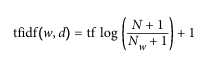

Di mana $N$ adalah jumlah dokumen dalam set pelatihan, $N_w$ adalah jumlah dokumen dalam set pelatihan yang mengandung kata $w$, dan $tf$ (term frequency) adalah berapa kali kata $w$ muncul dalam dokumen kueri $d$ (dokumen yang ingin Anda transformasi atau kodekan).Kedua kelas tersebut juga menerapkan normalisasi L2 setelah menghitung representasi tf–idf; dengan kata lain, keduanya menskalakan ulang representasi setiap dokumen agar memiliki norma Euclidean 1. Penskalaan dengan cara ini memastikan bahwa panjang suatu dokumen (jumlah kata) tidak mengubah representasi vektornya.Karena tf–idf memanfaatkan properti statistik dari data pelatihan, kita akan menggunakan pipeline, seperti yang dijelaskan di Bab 6, untuk memastikan hasil dari grid search kita valid. Hal ini mengarah pada kode berikut:

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(TfidfVectorizer(min_df=5, norm=None),
LogisticRegression())
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best cross-validation score: 0.72


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Seperti yang terlihat, terdapat peningkatan performa saat menggunakan tf–idf dibandingkan hanya menggunakan penghitungan kata biasa. Kita juga dapat memeriksa kata-kata mana yang dianggap paling penting oleh tf–idf. Perlu diingat bahwa penskalaan tf–idf ditujukan untuk menemukan kata-kata yang membedakan antar dokumen, namun teknik ini sepenuhnya bersifat *unsupervised*. Jadi, istilah "penting" di sini tidak selalu merujuk pada label "ulasan positif" atau "ulasan negatif" yang kita cari. Pertama-tama, kita ekstrak `TfidfVectorizer` dari *pipeline*:

In [29]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]

# transform the training dataset
X_train = vectorizer.transform(text_train)

# find maximum value for each of the features over the dataset
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()

# get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

print("Features with lowest tfidf:\n{}".format(
  feature_names[sorted_by_tfidf[:20]]
))
print("Features with highest tfidf: \n{}".format(
  feature_names[sorted_by_tfidf[-20:]]
))

Features with lowest tfidf:
['remained' 'acclaimed' 'combines' 'rapidly' 'uniformly' 'diverse'
 'avoiding' 'fills' 'feeble' 'admired' 'wherever' 'admission' 'abound'
 'starters' 'assure' 'pivotal' 'deliciously' 'comprehend' 'strung'
 'inadvertently']
Features with highest tfidf: 
['nukie' 'reno' 'dominick' 'taz' 'ling' 'rob' 'victoria' 'turtles'
 'khouri' 'lorenzo' 'id' 'zizek' 'elwood' 'nikita' 'rishi' 'timon'
 'titanic' 'zohan' 'pammy' 'godzilla']


Fitur dengan nilai tf–idf rendah adalah fitur yang sangat umum digunakan di berbagai dokumen atau hanya digunakan sesekali dalam dokumen yang sangat panjang. Menariknya, banyak fitur dengan tf–idf tinggi justru mengidentifikasi acara atau film tertentu. Istilah-istilah ini hanya muncul dalam ulasan untuk acara atau waralaba spesifik tersebut, tetapi cenderung muncul sangat sering di dalam ulasan-ulasan khusus itu.

Hal ini terlihat sangat jelas pada kata-kata seperti "pokemon", "smallville", dan "doodlebops", bahkan kata "scanners" di sini sebenarnya juga merujuk pada sebuah judul film. Kata-kata ini kecil kemungkinannya untuk membantu kita dalam tugas klasifikasi sentimen (kecuali jika ada waralaba tertentu yang secara universal diulas positif atau negatif), tetapi kata-kata tersebut tentu mengandung banyak informasi spesifik mengenai ulasan tersebut.

Kita juga dapat menemukan kata-kata yang memiliki *inverse document frequency* rendah—yaitu kata-kata yang sering muncul dan oleh karena itu dianggap kurang penting. Nilai *inverse document frequency* yang ditemukan pada set pelatihan disimpan dalam atribut `idf_`.

In [30]:
import numpy as np

sorted_by_idf = np.argsort(vectorizer.idf_)
print("Features with lowest idf:\n{}".format(
feature_names[sorted_by_idf[:100]]))

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'one' 'be' 'have' 'are' 'film' 'you' 'all'
 'at' 'an' 'by' 'from' 'so' 'like' 'who' 'there' 'they' 'his' 'if' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'can' 'good' 'when' 'more'
 'up' 'time' 'very' 'even' 'only' 'no' 'see' 'would' 'my' 'story' 'really'
 'which' 'well' 'had' 'me' 'than' 'their' 'much' 'were' 'get' 'other' 'do'
 'been' 'most' 'also' 'into' 'don' 'her' 'first' 'great' 'how' 'made'
 'people' 'will' 'make' 'because' 'way' 'could' 'bad' 'we' 'after' 'them'
 'too' 'any' 'then' 'movies' 'watch' 'she' 'think' 'seen' 'acting' 'its'
 'characters']


Sesuai perkiraan, kata-kata ini sebagian besar merupakan *stopwords* bahasa Inggris seperti "the" dan "no". Namun, beberapa di antaranya jelas bersifat spesifik untuk domain ulasan film, seperti "movie", "film", "time", "story", dan sebagainya.

Hal yang menarik adalah kata "good", "great", dan "bad" juga termasuk dalam jajaran kata yang paling sering muncul dan oleh karena itu dianggap sebagai kata yang "paling tidak relevan" menurut ukuran tf–idf, padahal kita mungkin mengharapkan kata-kata tersebut menjadi sangat penting untuk tugas analisis sentimen kita.

## Investigating Model Coefficients

Terakhir, mari kita pelajari lebih detail mengenai apa yang sebenarnya dipelajari oleh model regresi logistik kita dari data tersebut. Karena terdapat sangat banyak fitur—27.271 setelah menghapus fitur yang jarang muncul—kita jelas tidak bisa melihat semua koefisien secara bersamaan.

Namun, kita dapat melihat koefisien-koefisien terbesar dan memeriksa kata apa yang sesuai dengan koefisien tersebut. Kita akan menggunakan model terakhir yang telah dilatih berdasarkan fitur tf–idf. Diagram batang berikut (Gambar 7-2) menunjukkan 25 koefisien terbesar dan 25 koefisien terkecil dari model regresi logistik, dengan batang-batang yang menunjukkan ukuran dari setiap koefisien tersebut:

In [33]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 10.3 MB/s eta 0:00:00


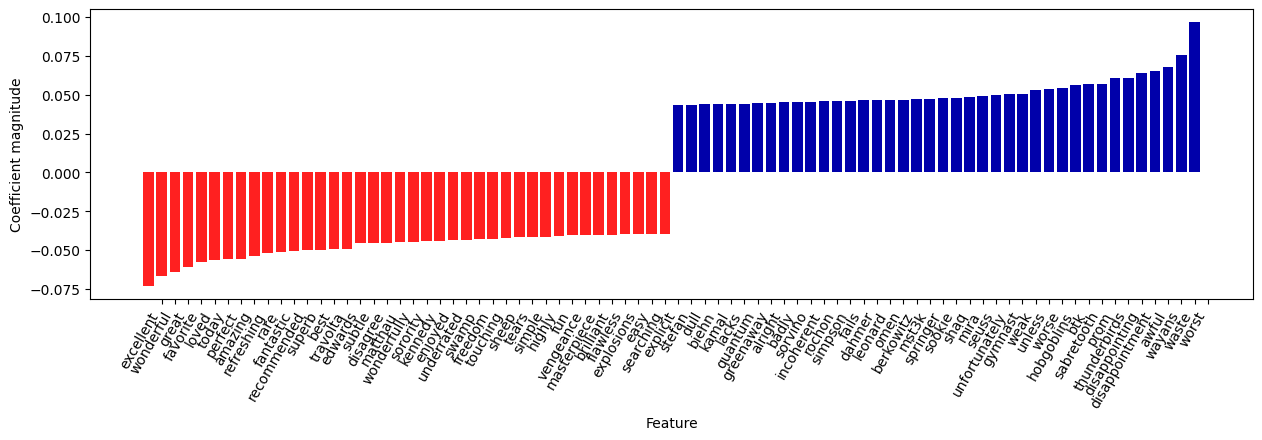

In [36]:
coef = grid.best_estimator_.named_steps["logisticregression"].coef_[0]

mglearn.tools.visualize_coefficients(
  coef,
  feature_names,
  n_top_features=40
)

Koefisien negatif di sisi kiri merupakan kata-kata yang menurut model mengindikasikan ulasan negatif, sedangkan koefisien positif di sisi kanan merupakan kata-kata yang mengindikasikan ulasan positif. Sebagian besar istilah tersebut cukup intuitif, seperti "**worst**", "**waste**", "**disappointment**", dan "**laughable**" yang menunjukkan ulasan film buruk, sementara "**excellent**", "**wonderful**", "**enjoyable**", dan "**refreshing**" menunjukkan ulasan film positif.

Beberapa kata terlihat sedikit kurang jelas, seperti "**bit**", "**job**", dan "**today**", namun kata-kata ini mungkin merupakan bagian dari frasa seperti "*good job*" atau "*best today*".

## Bag-of-Words with More Than One Word (n-Grams)

Salah satu kelemahan utama dari penggunaan representasi *bag-of-words* adalah urutan kata sepenuhnya diabaikan. Oleh karena itu, dua kalimat seperti "*it’s bad, not good at all*" dan "*it’s good, not bad at all*" memiliki representasi yang sama persis, padahal maknanya bertolak belakang. Menempatkan kata "*not*" di depan suatu kata hanyalah salah satu contoh bagaimana konteks sangat berpengaruh.

Untungnya, ada cara untuk menangkap konteks saat menggunakan representasi *bag-of-words*, yaitu dengan tidak hanya menghitung token tunggal, tetapi juga menghitung pasangan atau kumpulan tiga token yang muncul berurutan. Pasangan token dikenal sebagai **bigrams**, kumpulan tiga token disebut **trigrams**, dan secara lebih umum, urutan token dikenal sebagai **n-grams**.

Kita dapat mengubah rentang token yang dianggap sebagai fitur dengan mengubah parameter `ngram_range` pada `CountVectorizer` atau `TfidfVectorizer`. Parameter `ngram_range` adalah sebuah *tuple* yang terdiri dari panjang minimum dan panjang maksimum urutan token yang akan dipertimbangkan. Berikut adalah contoh pada data mainan (*toy data*) yang kita gunakan sebelumnya:

In [37]:
print("bards_words:\n{}".format(bards_words))

bards_words:
['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


Secara default, fitur dibuat per urutan token yang memiliki panjang minimal satu dan maksimal satu, atau dengan kata lain, tepat satu token panjangnya (token tunggal juga disebut sebagai unigrams):

In [41]:
cv = CountVectorizer(ngram_range=(1, 1)).fit(bards_words)

print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out()))

Vocabulary size: 13
Vocabulary:
['be' 'but' 'doth' 'fool' 'he' 'himself' 'is' 'knows' 'man' 'the' 'think'
 'to' 'wise']


Untuk hanya melihat bigrams—yaitu urutan dua token yang saling mengikuti—kita dapat mengatur ngram_range menjadi (2, 2):

In [43]:
cv = CountVectorizer(ngram_range=(2, 2)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out()))

Vocabulary size: 14
Vocabulary:
['be fool' 'but the' 'doth think' 'fool doth' 'he is' 'himself to'
 'is wise' 'knows himself' 'man knows' 'the fool' 'the wise' 'think he'
 'to be' 'wise man']


Menggunakan urutan token yang lebih panjang biasanya menghasilkan jauh lebih banyak fitur, dan fitur-fitur tersebut menjadi lebih spesifik. Tidak ada *bigram* yang sama di antara kedua frasa dalam `bards_words`.

In [44]:
print("Transformed data (dense):\n{}".format(cv.transform(bards_words).toarray()))

Transformed data (dense):
[[0 0 1 1 1 0 1 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 1 0 1 0 1 1]]


Untuk sebagian besar aplikasi, jumlah minimum token harus satu, karena kata tunggal sering kali menangkap banyak makna. Menambahkan *bigrams* membantu dalam banyak kasus. Menambahkan urutan yang lebih panjang—hingga *5-grams*—mungkin bisa membantu juga, tetapi hal ini akan menyebabkan lonjakan jumlah fitur dan bisa memicu *overfitting*, karena akan ada banyak fitur yang sangat spesifik.

Secara prinsip, jumlah *bigrams* bisa sebanyak kuadrat dari jumlah *unigrams*, dan jumlah *trigrams* bisa sebanyak jumlah *unigrams* pangkat tiga, yang mengarah pada ruang fitur yang sangat besar. Dalam praktiknya, jumlah *n-grams* yang lebih tinggi yang benar-benar muncul dalam data jauh lebih kecil karena struktur bahasa (Inggris), meskipun jumlahnya tetap besar.

Berikut adalah tampilan penggunaan *unigrams*, *bigrams*, dan *trigrams* pada `bards_words`:

In [46]:
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out()))

Vocabulary size: 39
Vocabulary:
['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


Mari kita coba TfidfVectorizer pada data ulasan film IMDb dan cari pengaturan ngram_range terbaik menggunakan grid search

In [ ]:
pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression())

# running the grid search takes a long time because of the
# relatively large grid and the inclusion of trigrams
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100],
"tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]}
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)

print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Seperti yang terlihat dari hasilnya, kita meningkatkan performa sedikit lebih dari satu persen dengan menambahkan fitur *bigram* dan *trigram*. Kita dapat memvisualisasikan akurasi validasi silang sebagai fungsi dari parameter `ngram_range` dan `C` dalam bentuk *heat map*, seperti yang kita lakukan di Bab 5 (lihat Gambar 7-3).

In [ ]:
# extract scores from grid_search
scores = grid.cv_results_['mean_test_score'].reshape(-1, 3).T
# visualize heat map
heatmap = mglearn.tools.heatmap(
scores, xlabel="C", ylabel="ngram_range", cmap="viridis", fmt="%.3f",
xticklabels=param_grid['logisticregression__C'],
yticklabels=param_grid['tfidfvectorizer__ngram_range'])
plt.colorbar(heatmap)